# 03 — PCA Analysis

**ML-Assisted Electrochemical Descriptor Analysis of Plasmonic Ag/Au g-C3N4 Photocatalysts**

- **Section A** — PCA at catalyst level (n=7), computed separately per illumination condition
- **Section B** — PCA at measurement level (n=84), colored by metal, condition, and loading
- **Section C** — PCA feature loading heatmap, showing which descriptors drive each component

**Inputs:** `Results/TABLE2_catalyst_n28.csv`, `Results/MASTER_TABLE_n84.csv`
**Run after** `01_data_preparation.ipynb`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from utils import SAMPLE_COLORS, CONDITION_COLORS

sample_colors = SAMPLE_COLORS
sample_marker = {
    "C3N4": "o",
    "Ag0.25": "s", "Ag0.5": "s", "Ag1": "s",
    "Au0.25": "^", "Au0.5": "^", "Au1": "^",
}
metal_colors = {"Ag": "#2471A3", "Au": "#E67E22"}
cond_colors  = CONDITION_COLORS
load_colors  = {0.25: "#E74C3C", 0.5: "#F1C40F", 1.0: "#1ABC9C"}

df7  = pd.read_csv("Results/TABLE2_catalyst_n28.csv")
df84 = pd.read_csv("Results/MASTER_TABLE_n84.csv")
print(f"TABLE2: {df7.shape} | MASTER: {df84.shape}")

TABLE2: (28, 42) | MASTER: (84, 48)


## A. PCA at Catalyst Level (n=7) — Per Illumination Condition

Each condition is analyzed separately so that the mix of active mechanisms
(dark Schottky behavior vs. LSPR-driven photoresponse) doesn't get mixed
into a single set of components.

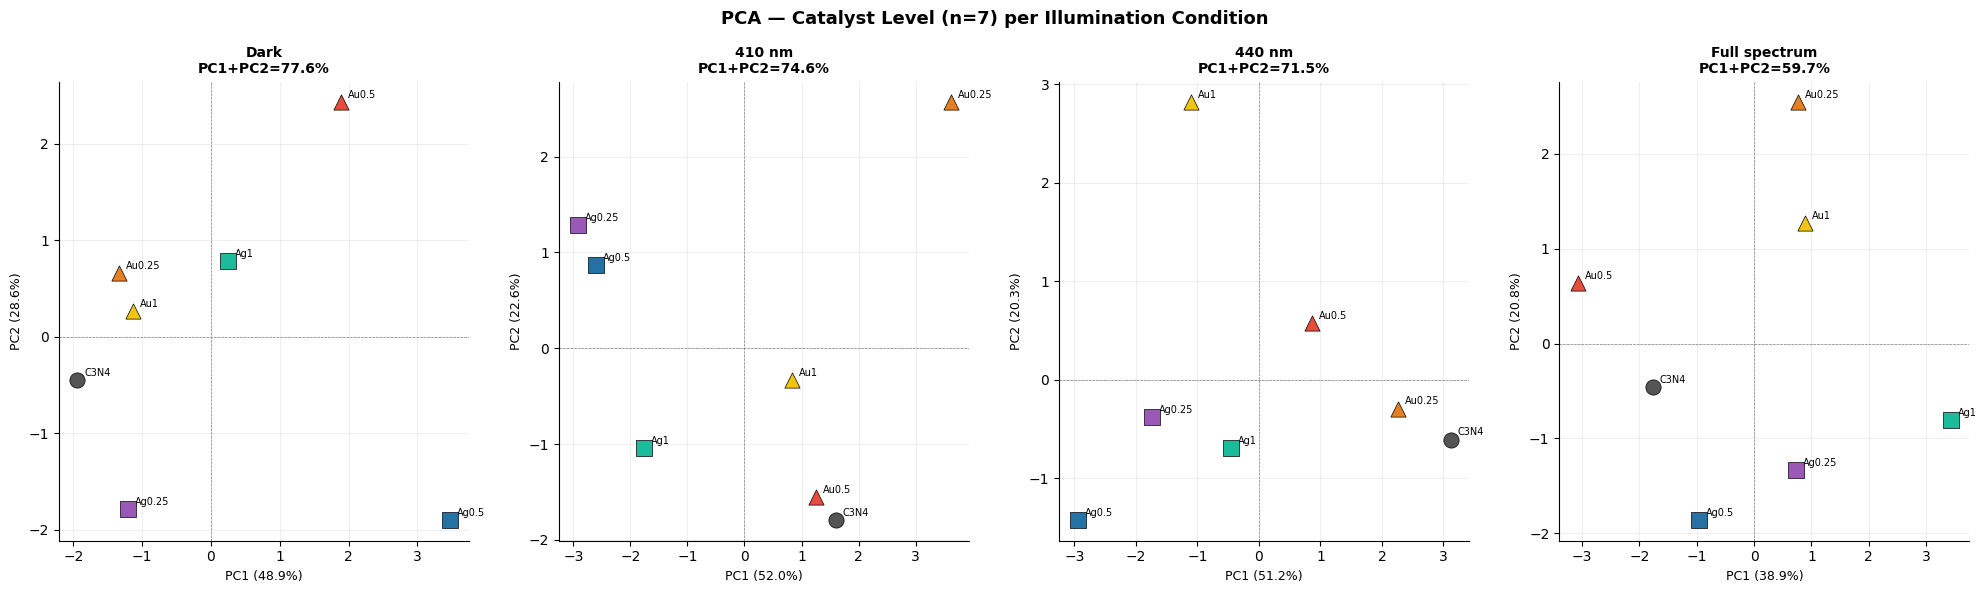

Saved: Results/PCA_per_condition.png


In [2]:
pca_features = [
    "Vfb_V", "Eg_eV", "Rct_ohm", "Rs_ohm", "tau_s",
    "phase_min", "Cdl_est_F", "delta_Rct",
    "CA_dJ_mean_mA", "CA_stability",
]
conditions = ["Dark", "410 nm", "440 nm", "Full spectrum"]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.patch.set_facecolor("white")

pca_results = {}

for ax, cond in zip(axes, conditions):
    sub = df7[df7["condition"] == cond].copy().set_index("sample")
    feat_avail = [c for c in pca_features if c in sub.columns]
    X = sub[feat_avail].dropna(axis=1, how="any").dropna(axis=0, how="any")

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca      = PCA(n_components=2)
    scores   = pca.fit_transform(X_scaled)
    var_exp  = pca.explained_variance_ratio_ * 100

    pca_results[cond] = {
        "pca": pca, "scores": scores, "samples": X.index.tolist(),
        "features": feat_avail, "var_exp": var_exp
    }

    for i, sample in enumerate(X.index):
        ax.scatter(scores[i, 0], scores[i, 1],
                   color=sample_colors.get(sample, "#888888"),
                   marker=sample_marker.get(sample, "o"),
                   s=120, zorder=5, edgecolors="black", linewidths=0.5)
        ax.annotate(sample, (scores[i, 0], scores[i, 1]),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)

    ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=9)
    ax.set_title(f"{cond}\nPC1+PC2={sum(var_exp):.1f}%",
                 fontweight="bold", fontsize=10)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("PCA — Catalyst Level (n=7) per Illumination Condition",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Results/PCA_per_condition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Results/PCA_per_condition.png")

**PCA — catalyst level (n=7) per condition**

PC1+PC2 captures 59.7-77.6% of variance depending on condition. Variance explained is
highest at Dark (77.6%), consistent with fewer active mechanisms in the absence of
illumination, and lowest at Full spectrum (59.7%), consistent with multiple competing
processes being active simultaneously.

- **Dark (PC1+PC2=77.6%)** — C3N4 is isolated at negative PC2. Ag0.5 and Au0.5 cluster
  at positive PC1: mid-loading catalysts show the strongest Schottky-barrier fingerprint
  in the dark EIS.
- **410 nm (PC1+PC2=74.6%)** — the Ag series spreads along PC1 in order of loading,
  consistent with a monotonic LSPR response at the Ag resonance wavelength. Au0.25 sits
  far along positive PC2, an anomalous capacitive response.
- **440 nm (PC1+PC2=71.5%)** — Ag0.5 is strongly negative on PC2, the maximum capacitive
  interface response at 440 nm despite the Ag LSPR resonance sitting at 410 nm, suggesting
  a secondary excitation pathway near the g-C3N4 band gap (2.86 eV, approx. 433 nm)
  enhanced by Ag at 0.5 wt%.
- **Full spectrum (PC1+PC2=59.7%)** — the lowest variance explained: the descriptor space
  is most diffuse under broadband illumination, and no clear separation emerges in 2D
  with all mechanisms active at once.

## B. PCA at Measurement Level (n=84) — Master Table

Applied to the full master table, using the same descriptor set as Section A.

In [3]:
df84_pca = df84[pca_features + ["metal", "condition", "sample", "loading_num"]].dropna().reset_index(drop=True)

X84 = df84_pca[pca_features].values
scaler84 = StandardScaler()
X84_scaled = scaler84.fit_transform(X84)

pca84 = PCA(n_components=4)
scores_np = pca84.fit_transform(X84_scaled)
var_exp = pca84.explained_variance_ratio_ * 100

metals_arr = df84_pca["metal"].values
conditions_arr = df84_pca["condition"].values
samples_arr = df84_pca["sample"].values
loading_vals = df84_pca["loading_num"].values

print(f"n={len(df84_pca)}, features={pca_features}")
print(f"Variance explained: PC1={var_exp[0]:.1f}%, PC2={var_exp[1]:.1f}%, "
      f"PC3={var_exp[2]:.1f}%, PC4={var_exp[3]:.1f}%, total(PC1-4)={sum(var_exp):.1f}%")

n=84, features=['Vfb_V', 'Eg_eV', 'Rct_ohm', 'Rs_ohm', 'tau_s', 'phase_min', 'Cdl_est_F', 'delta_Rct', 'CA_dJ_mean_mA', 'CA_stability']
Variance explained: PC1=26.1%, PC2=19.9%, PC3=14.6%, PC4=12.7%, total(PC1-4)=73.3%


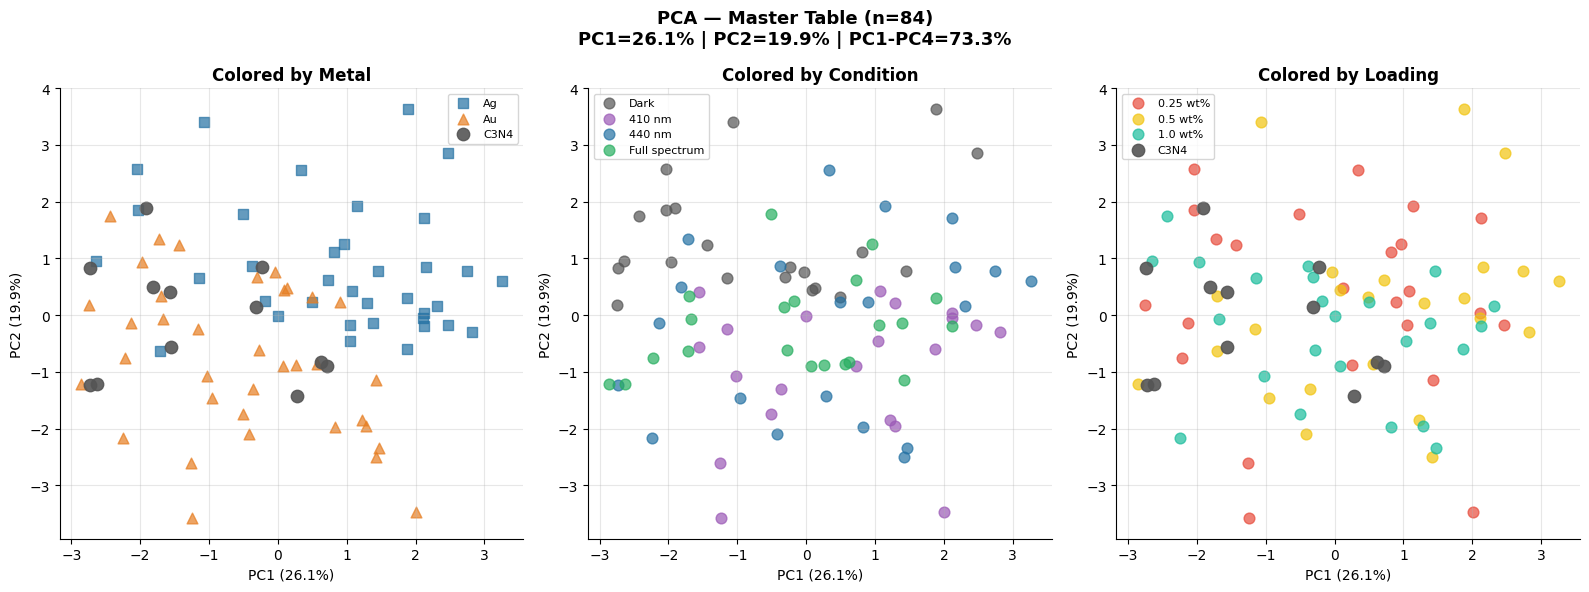

Saved: Results/PCA_master_n84.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot 1: Metal
ax = axes[0]
for metal, color in metal_colors.items():
    mask = metals_arr == metal
    ax.scatter(scores_np[mask, 0], scores_np[mask, 1],
               color=color, label=metal, alpha=0.7, s=60,
               marker="s" if metal == "Ag" else "^")
mask_c = samples_arr == "C3N4"
ax.scatter(scores_np[mask_c, 0], scores_np[mask_c, 1],
           color="#555555", label="C3N4", alpha=0.9, s=80, marker="o")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=10)
ax.set_title("Colored by Metal", fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Plot 2: Condition
ax = axes[1]
for cond, color in cond_colors.items():
    mask = conditions_arr == cond
    ax.scatter(scores_np[mask, 0], scores_np[mask, 1],
               color=color, label=cond, alpha=0.7, s=60)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=10)
ax.set_title("Colored by Condition", fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Plot 3: Loading
ax = axes[2]
for load, color in load_colors.items():
    mask = np.isclose(loading_vals, load)
    ax.scatter(scores_np[mask, 0], scores_np[mask, 1],
               color=color, label=f"{load} wt%", alpha=0.7, s=60)
ax.scatter(scores_np[mask_c, 0], scores_np[mask_c, 1],
           color="#555555", label="C3N4", alpha=0.9, s=80, marker="o")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=10)
ax.set_title("Colored by Loading", fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.suptitle(f"PCA — Master Table (n=84)\n"
             f"PC1={var_exp[0]:.1f}% | PC2={var_exp[1]:.1f}% | "
             f"PC1-PC4={sum(var_exp[:4]):.1f}%",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("Results/PCA_master_n84.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Results/PCA_master_n84.png")

**Findings:**

- **Metal** — Ag (squares) and Au (triangles) partially separate, confirming the two
  metals have distinct descriptor profiles; C3N4 sits at a distinct position.
- **Condition** — no clean separation by illumination condition: wavelength effects are
  distributed across higher PCs rather than captured in PC1-PC2.
- **Loading** — no clean separation by loading: loading differences are small relative
  to the total descriptor variance.

Metal identity is the strongest separator in descriptor space at n=84; condition and
loading effects require higher components to resolve, which Section C examines directly.

## C. PCA Feature Loading Heatmap

Shows how strongly each descriptor contributes to each principal component. Red is a
positive loading (the feature increases with the PC score), blue is negative.

The feature set below excludes descriptors that are deterministic functions of another
descriptor already included — `Rct_ratio` and `Rct_ratio_mean` (functions of `Rct_ohm`
and `Rct_dark`) and `delta_Rct_mean` (a function of `delta_Rct`) — following the same
target-specific exclusion convention used throughout this project (see `utils.py`).
Carrying both a raw quantity and its derived transform into a PCA inflates whichever
component they happen to align with, without adding independent information.

In [5]:
features_ext = [
    "Rs_ohm", "Rct_ohm", "tau_s", "phase_min", "Cdl_est_F",
    "Vfb_V", "Eg_eV", "delta_Rct",
    "CA_dJ_mean_mA", "CA_stability", "TEM_mean_nm",
    "SSPL_quenching_ratio", "TRPL_tau_A_ns", "XRD_metal_tau_nm",
    "loading_num", "condition_num", "voltage",
    "E_onset_V", "|tafel|_mV_dec", "CA_spike_mA",
    "Rct_dark", "delta_Rs",
]
print(f"Feature count: {len(features_ext)}")

df_ext = df84[features_ext].dropna().reset_index(drop=True)
X_ext  = StandardScaler().fit_transform(df_ext.values)
pca6   = PCA(n_components=6)
pca6.fit(X_ext)
loadings = pca6.components_
var6     = pca6.explained_variance_ratio_ * 100

print("\nTop 5 features per PC:")
for i in range(4):
    idx_top = np.argsort(np.abs(pca6.components_[i]))[::-1][:5]
    print(f"\nPC{i+1} ({var6[i]:.1f}%):")
    for j in idx_top:
        print(f"  {features_ext[j]:<25} {pca6.components_[i, j]:+.3f}")

Feature count: 22

Top 5 features per PC:

PC1 (16.9%):
  phase_min                 -0.436
  tau_s                     +0.388
  Rct_ohm                   +0.373
  voltage                   +0.310
  TEM_mean_nm               -0.305

PC2 (14.6%):
  CA_stability              +0.486
  CA_spike_mA               +0.422
  CA_dJ_mean_mA             +0.417
  Rct_dark                  +0.380
  condition_num             +0.280

PC3 (13.9%):
  Eg_eV                     +0.514
  SSPL_quenching_ratio      +0.431
  Rs_ohm                    +0.351
  TEM_mean_nm               +0.273
  TRPL_tau_A_ns             +0.272

PC4 (12.3%):
  voltage                   -0.402
  loading_num               -0.361
  Rct_ohm                   -0.360
  XRD_metal_tau_nm          -0.343
  SSPL_quenching_ratio      +0.292


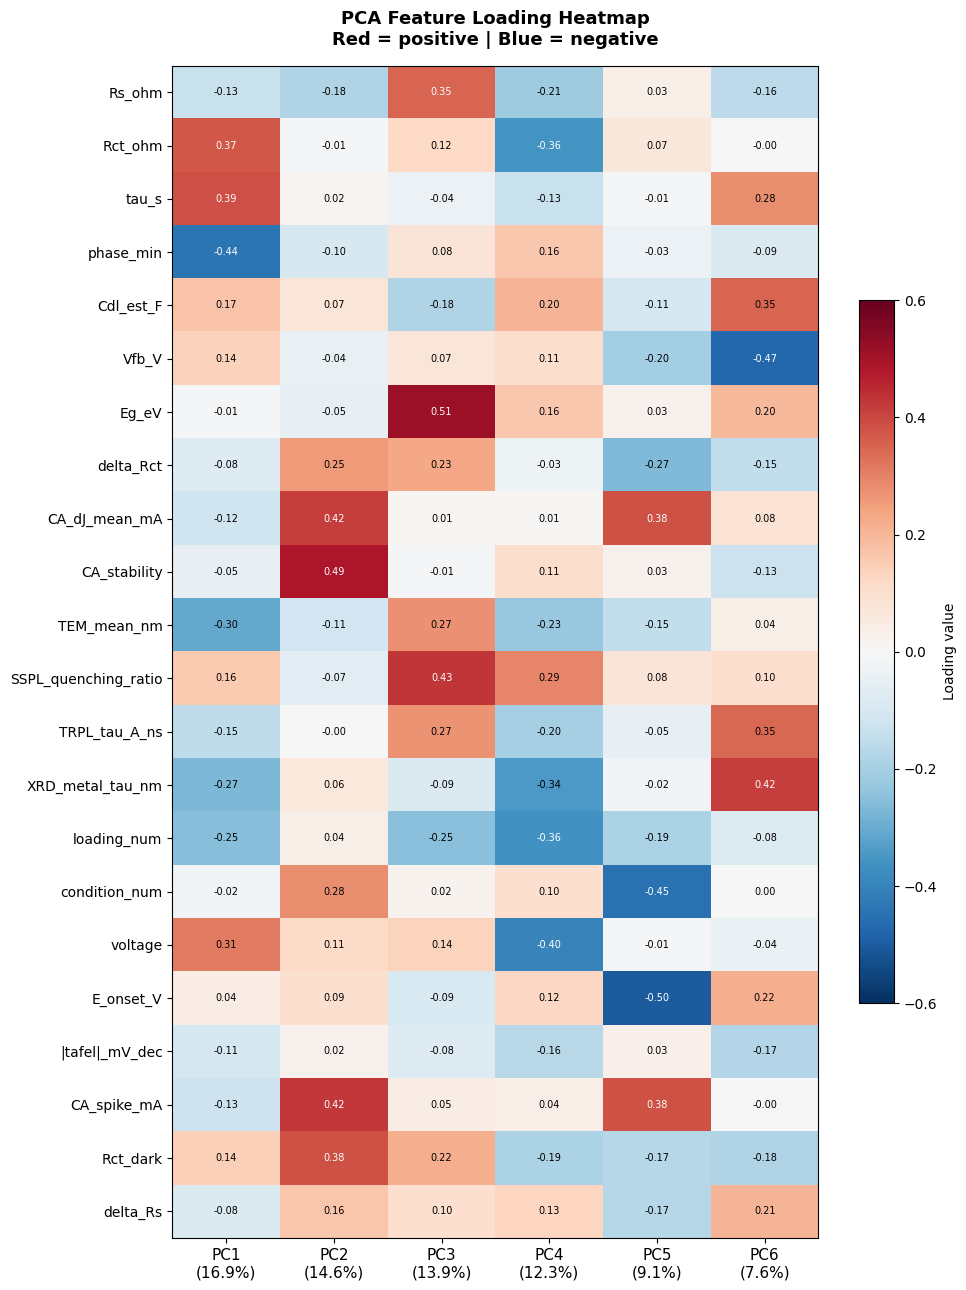

Saved: Results/PCA_loading_heatmap.png


In [6]:
fig1, ax1 = plt.subplots(figsize=(10, 13))
loading_matrix = loadings[:6, :].T
im = ax1.imshow(loading_matrix, cmap="RdBu_r", vmin=-0.6, vmax=0.6, aspect="auto")
plt.colorbar(im, ax=ax1, label="Loading value", shrink=0.6)
ax1.set_xticks(range(6))
ax1.set_xticklabels([f"PC{i+1}\n({var6[i]:.1f}%)" for i in range(6)], fontsize=11)
ax1.set_yticks(range(len(features_ext)))
ax1.set_yticklabels(features_ext, fontsize=10)
ax1.set_title("PCA Feature Loading Heatmap\nRed = positive | Blue = negative",
              fontweight="bold", fontsize=13, pad=15)
for i in range(len(features_ext)):
    for j in range(6):
        val = loading_matrix[i, j]
        color = "white" if abs(val) > 0.35 else "black"
        ax1.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=7, color=color)
plt.tight_layout()
plt.savefig("Results/PCA_loading_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Results/PCA_loading_heatmap.png")

**Component character:**

- **PC1 (16.9%)** — interface kinetics: `phase_min`, `tau_s`, `Rct_ohm`, `voltage`
- **PC2 (14.6%)** — chronoamperometric photoresponse: `CA_stability`, `CA_spike_mA`,
  `CA_dJ_mean_mA`, `Rct_dark`
- **PC3 (13.9%)** — optical/synthesis axis: `Eg_eV`, `SSPL_quenching_ratio`, `Rs_ohm`,
  `TRPL_tau_A_ns`
- **PC4 (12.3%)** — loading/morphology: `voltage`, `loading_num`, `Rct_ohm`,
  `XRD_metal_tau_nm`

EIS kinetics (PC1), photoresponse dynamics (PC2), and optical/structural descriptors
(PC3) separate cleanly onto distinct components, confirming they carry largely
independent information — this is what justifies including both EIS-derived and
characterization descriptors together in the RF/GPR models in later notebooks
(`delta_Rs` is likewise retained as an independent raw measurement: it is essentially
uncorrelated with `Rs_ohm`, r approx. -0.04, rather than a derived transform of it).